# 📊 Notebook 00 — EDA & Data Preprocessing
**Project**: Resume Named Entity Recognition (NER)  
**Purpose**: Explore the dataset, clean annotation issues, and prepare train/test splits for all downstream models.

> ⚠️ **Run this notebook first.** It outputs `data/` files used by all other notebooks.


In [ ]:
!pip install spacy matplotlib seaborn -q

In [1]:
import json, random, os
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

random.seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

Path("data").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Load Raw Data

In [ ]:
DATA_PATH = "train_data.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print(f"✅ Loaded {len(raw_data)} resume samples")
print(f"Format: [text (str), {{entities: [[start, end, label], ...]}}]")
print(f"\nSample text (first 300 chars):")
print(raw_data[0][0][:300])


✅ Loaded 200 resume samples
Format: [text (str), {entities: [[start, end, label], ...]}]

Sample text (first 300 chars):
Govardhana K Senior Software Engineer  Bengaluru, Karnataka, Karnataka - Email me on Indeed: indeed.com/r/Govardhana-K/ b2de315d95905b68  Total IT experience 5 Years 6 Months Cloud Lending Solutions INC 4 Month • Salesforce Developer Oracle 5 Years 2 Month • Core Java Developer Languages Core Java, 


In [3]:
# Preview first 5 entity annotations
text, ann = raw_data[0]
print("Sample entities from first resume:")
for ent in ann['entities'][:6]:
    s, e, lbl = ent
    print(f"  [{lbl:25s}] → \"{text[s:e][:60]}\"")


Sample entities from first resume:
  [Companies worked at      ] → "Oracle"
  [Companies worked at      ] → "Oracle"
  [Companies worked at      ] → "Oracle"
  [Skills                   ] → "Languages: Core Java, Go Lang, Data Structures & Algorithms,"
  [Companies worked at      ] → "Oracle"
  [Skills                   ] → "APEX. (Less than 1 year), Data Structures (3 years), FLEXCUB"


## 2. Exploratory Data Analysis

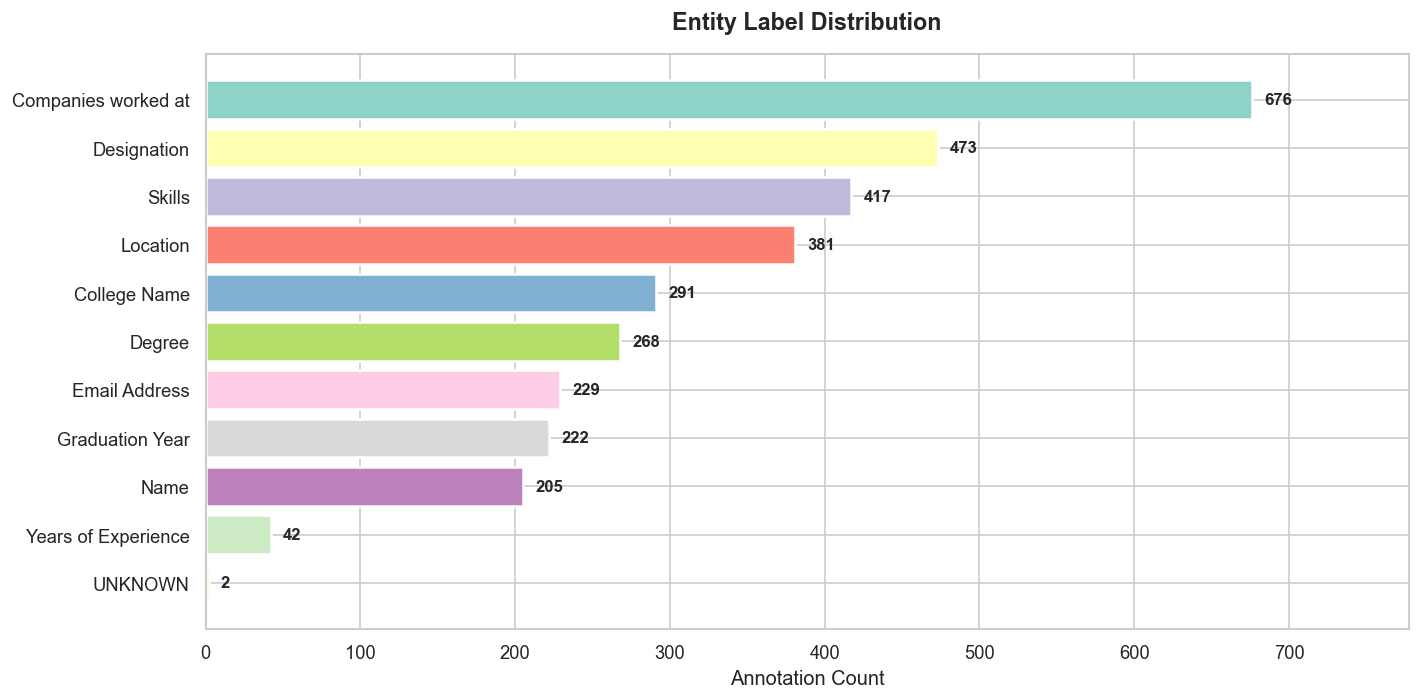

Label counts: {'Companies worked at': 676, 'Skills': 417, 'Graduation Year': 222, 'College Name': 291, 'Degree': 268, 'Designation': 473, 'Email Address': 229, 'Location': 381, 'Name': 205, 'Years of Experience': 42, 'UNKNOWN': 2}


In [4]:
# ── Label distribution ──────────────────────────────────────────
all_labels = [ent[2] for text, ann in raw_data for ent in ann['entities']]
label_counts = Counter(all_labels)

fig, ax = plt.subplots(figsize=(12, 6))
labels_sorted = [l for l, c in label_counts.most_common()]
counts_sorted = [c for l, c in label_counts.most_common()]
colors = plt.cm.Set3(np.linspace(0, 1, len(labels_sorted)))

bars = ax.barh(labels_sorted[::-1], counts_sorted[::-1], color=colors[::-1], edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts_sorted[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            str(cnt), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("Annotation Count", fontsize=12)
ax.set_title("Entity Label Distribution", fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, max(counts_sorted) * 1.15)
plt.tight_layout()
plt.savefig("data/label_distribution.png", bbox_inches='tight')
plt.show()
print("Label counts:", dict(label_counts))


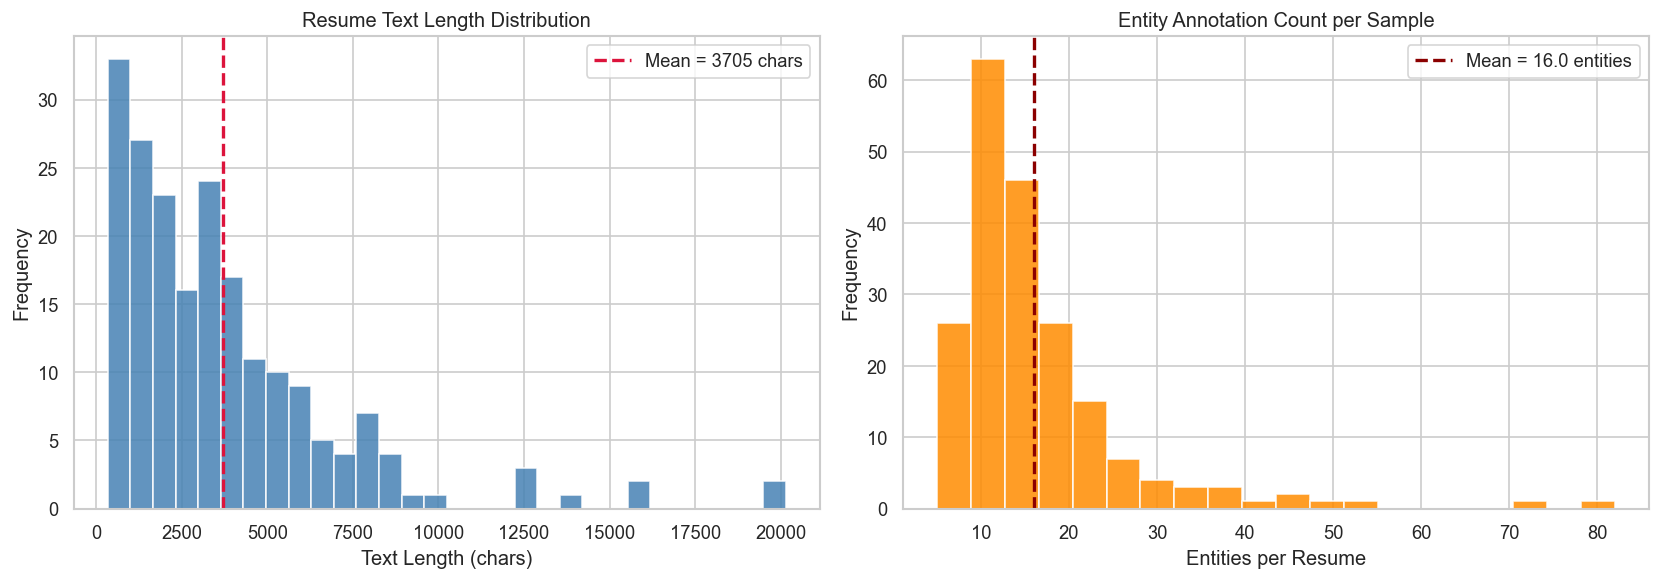

Text length  — Min: 346, Max: 20143, Mean: 3705
Entities/doc — Min: 5, Max: 82, Mean: 16.0


In [5]:
# ── Text & entity count distributions ───────────────────────────
text_lengths     = [len(text) for text, _ in raw_data]
entities_per_doc = [len(ann['entities']) for _, ann in raw_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(text_lengths, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(text_lengths), color='crimson', ls='--', lw=2,
                label=f'Mean = {np.mean(text_lengths):.0f} chars')
axes[0].set(xlabel='Text Length (chars)', ylabel='Frequency',
            title='Resume Text Length Distribution')
axes[0].legend()

axes[1].hist(entities_per_doc, bins=20, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(entities_per_doc), color='darkred', ls='--', lw=2,
                label=f'Mean = {np.mean(entities_per_doc):.1f} entities')
axes[1].set(xlabel='Entities per Resume', ylabel='Frequency',
            title='Entity Annotation Count per Sample')
axes[1].legend()

plt.tight_layout()
plt.savefig("data/text_stats.png", bbox_inches='tight')
plt.show()
print(f"Text length  — Min: {min(text_lengths)}, Max: {max(text_lengths)}, Mean: {np.mean(text_lengths):.0f}")
print(f"Entities/doc — Min: {min(entities_per_doc)}, Max: {max(entities_per_doc)}, Mean: {np.mean(entities_per_doc):.1f}")


## 3. Data Quality Check

In [6]:
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

bad_spans, unknown_ents = [], []

for idx, (text, ann) in enumerate(raw_data):
    for ent in ann['entities']:
        s, e, lbl = ent
        if lbl == 'UNKNOWN':
            unknown_ents.append(idx)
        if s >= e or e > len(text) or s < 0:
            bad_spans.append((idx, s, e, lbl, len(text)))
            print(f"  ⚠️  BAD SPAN at sample {idx}: [{s}, {e}] label='{lbl}' text_len={len(text)}")

print(f"\nBad spans found  : {len(bad_spans)}")
print(f"UNKNOWN labels   : {len(unknown_ents)}")

# Check for overlapping spans
overlap_count = 0
for idx, (text, ann) in enumerate(raw_data):
    ents = sorted(ann['entities'], key=lambda x: x[0])
    for i in range(len(ents)-1):
        if ents[i][1] > ents[i+1][0]:
            overlap_count += 1

print(f"Overlapping spans: {overlap_count}")
print("\n✅ Summary: 1 bad span + 2 UNKNOWN labels + overlaps will be cleaned.")


DATA QUALITY REPORT
  ⚠️  BAD SPAN at sample 118: [3884, 3880] label='Graduation Year' text_len=4374

Bad spans found  : 1
UNKNOWN labels   : 2
Overlapping spans: 83

✅ Summary: 1 bad span + 2 UNKNOWN labels + overlaps will be cleaned.


## 4. Data Cleaning

In [7]:
LABELS_TO_KEEP = {
    'Name', 'Email Address', 'Skills', 'Degree', 'College Name',
    'Location', 'Companies worked at', 'Designation',
    'Graduation Year', 'Years of Experience'
}

def clean_data(raw_data):
    """
    Cleaning steps:
    1. Remove UNKNOWN labels
    2. Remove invalid/inverted spans
    3. Resolve overlapping spans — keep the longer entity
    """
    cleaned, stats = [], Counter()
    
    for text, ann in raw_data:
        filtered = []
        for s, e, lbl in ann['entities']:
            if lbl not in LABELS_TO_KEEP:
                stats['removed_unknown'] += 1; continue
            if s >= e or e > len(text) or s < 0:
                stats['removed_bad_span'] += 1; continue
            filtered.append((s, e, lbl))

        # Resolve overlaps: sort by start, keep longest on conflict
        filtered.sort(key=lambda x: x[0])
        resolved = []
        for ent in filtered:
            if not resolved:
                resolved.append(ent)
            else:
                prev = resolved[-1]
                if ent[0] < prev[1]:              # overlap detected
                    if (ent[1]-ent[0]) > (prev[1]-prev[0]):
                        resolved[-1] = ent        # replace with longer
                    stats['removed_overlap'] += 1
                else:
                    resolved.append(ent)

        cleaned.append((text, {"entities": resolved}))

    print("Cleaning statistics:")
    for k, v in stats.items():
        print(f"  {k}: {v}")
    return cleaned

cleaned_data = clean_data(raw_data)
print(f"\n✅ Cleaned {len(cleaned_data)} samples")


Cleaning statistics:
  removed_overlap: 110
  removed_unknown: 2
  removed_bad_span: 1

✅ Cleaned 200 samples


## 5. Train / Test Split (80 / 20)

In [8]:
random.shuffle(cleaned_data)
split_idx  = int(len(cleaned_data) * 0.8)
train_data = cleaned_data[:split_idx]
test_data  = cleaned_data[split_idx:]

print(f"Train samples : {len(train_data)}")
print(f"Test  samples : {len(test_data)}")

# Verify label coverage in both splits
train_labels = Counter(e[2] for t,a in train_data for e in a['entities'])
test_labels  = Counter(e[2] for t,a in test_data  for e in a['entities'])
print("\nLabel coverage (train | test):")
for lbl in sorted(LABELS_TO_KEEP):
    print(f"  {lbl:30s} {train_labels.get(lbl,0):4d} | {test_labels.get(lbl,0):4d}")


Train samples : 160
Test  samples : 40

Label coverage (train | test):
  College Name                    234 |   55
  Companies worked at             498 |  120
  Degree                          223 |   44
  Designation                     358 |  100
  Email Address                   185 |   43
  Graduation Year                 188 |   29
  Location                        305 |   67
  Name                            165 |   40
  Skills                          351 |   50
  Years of Experience              28 |   10


## 6. Save Processed Data

In [9]:
def to_json_serializable(data):
    return [(text, {"entities": [list(e) for e in ann["entities"]]})
            for text, ann in data]

json.dump(to_json_serializable(train_data),
          open("data/train.json", "w", encoding="utf-8"), ensure_ascii=False)
json.dump(to_json_serializable(test_data),
          open("data/test.json",  "w", encoding="utf-8"), ensure_ascii=False)

ENTITY_LABELS = sorted({e[2] for t,a in cleaned_data for e in a['entities']})
json.dump(ENTITY_LABELS, open("data/labels.json", "w"))

print("Files saved to data/:")
for f in Path("data").iterdir():
    print(f"  {f.name} ({f.stat().st_size:,} bytes)")
print(f"\nEntity labels ({len(ENTITY_LABELS)}):", ENTITY_LABELS)


Files saved to data/:
  labels.json (153 bytes)
  label_distribution.png (53,858 bytes)
  test.json (153,352 bytes)
  text_stats.png (52,681 bytes)
  train.json (686,488 bytes)

Entity labels (10): ['College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Location', 'Name', 'Skills', 'Years of Experience']


In [10]:
# ── Convert to spaCy DocBin (for Notebooks 01 & 02) ─────────────
import spacy
from spacy.tokens import DocBin
from spacy.training import Example

def to_docbin(data, path):
    nlp = spacy.blank("en")
    db  = DocBin()
    skipped = 0
    for text, ann in data:
        doc = nlp.make_doc(text)
        try:
            example = Example.from_dict(doc, ann)
            db.add(example.reference)
        except Exception as e:
            skipped += 1
    db.to_disk(path)
    print(f"  Saved {len(data)-skipped} docs → {path}  (skipped {skipped})")

print("Converting to spaCy DocBin format...")
to_docbin(train_data, "data/train.spacy")
to_docbin(test_data,  "data/test.spacy")
print("\n🎉 Preprocessing complete! data/ folder is ready.")


Converting to spaCy DocBin format...


c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Aarti Pimplay Operations Center Shift Manager (OCS..." with entities "[(0, 13, 'Name'), (14, 52, 'Designation'), (76, 11...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Karthik G V Program Manager, Product Manager, Prod..." with entities "[(0, 11, 'Name'), (12, 28, 'Designation'), (136, 1...". Use `s

  Saved 160 docs → data/train.spacy  (skipped 0)
  Saved 40 docs → data/test.spacy  (skipped 0)

🎉 Preprocessing complete! data/ folder is ready.


c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Sudaya Puranik Principal Engineer Technical Staff ..." with entities "[(0, 14, 'Name'), (15, 49, 'Designation'), (52, 61...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Senthil Kumar Senior Technical Lead - HCL Cisco  -..." with entities "[(0, 13, 'Name'), (14, 35, 'Designation'), (38, 41...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserW